In [10]:
import pandas as pd
import os
from pathlib import Path

# Find data files (handles common issues)
data_dir = Path("..") / "data"
possible_files = [
    data_dir / "analysis_ready_credit_applications.csv",
    data_dir / "clean_credit_applications.csv",
    data_dir / "normalized_credit_applications.csv",
    Path("../data/raw_credit_applications.json")  # Fallback to raw
]

csv_file = None
for f in possible_files:
    if f.exists():
        csv_file = f
        print(f"Found: {csv_file}")
        break

if csv_file and csv_file.suffix == '.csv':
    df = pd.read_csv(csv_file)
elif csv_file and csv_file.suffix == '.json':
    import json
    with open(csv_file, 'r') as f:
        raw_data = json.load(f)
    df = pd.json_normalize(raw_data)
    print("Loaded & normalized raw JSON")
else:
    print("No data found! Check paths or run engineer's code first.")
    print("Current dir:", os.getcwd())
    print("Files:", [p.name for p in Path(".").glob("*")])
    raise FileNotFoundError("Data not found—run engineer's pipeline or adjust path.")

print("Shape:", df.shape)
print("\nColumns sample:", df.columns[:5].tolist())

Found: ../data/clean_credit_applications.csv
Shape: (500, 21)

Columns sample: ['_id', 'spending_behavior', 'processing_timestamp', 'applicant_info.full_name', 'applicant_info.email']


Key columns available:
['applicant_info.gender', 'decision.loan_approved', 'decision.approved_amount', 'gender_norm']
Valid records: 387

Approval Rates:
               mean  count
gender_norm              
Female       0.523    193
Male         0.675    194
Gender DIR: 0.775 (<0.8 = adverse impact)
Chi-square p-value: 0.003 (<0.05 = significant)

GENDER BIAS - STATISTICAL ANALYSIS SUMMARY
---------------------------------------------
Contingency table shape: (2, 2)
Chi-squared statistic: 8.68
p-value: 0.003
Degrees of freedom: 1
Result: Statistically significant gender-outcome association (p < 0.05)

Expected vs observed counts:
   Expected  Observed
0      77.3        92
1     115.7       101
2      77.7        63
3     116.3       131

Disparate Impact Ratio (DIR): 0.775
Regulatory finding: DIR < 0.8 violates four-fifths rule

Effect size interpretation:
Female approval rate: 52.3% (n=193)
Male approval rate:   67.5% (n=194)
Absolute difference:  15.2%


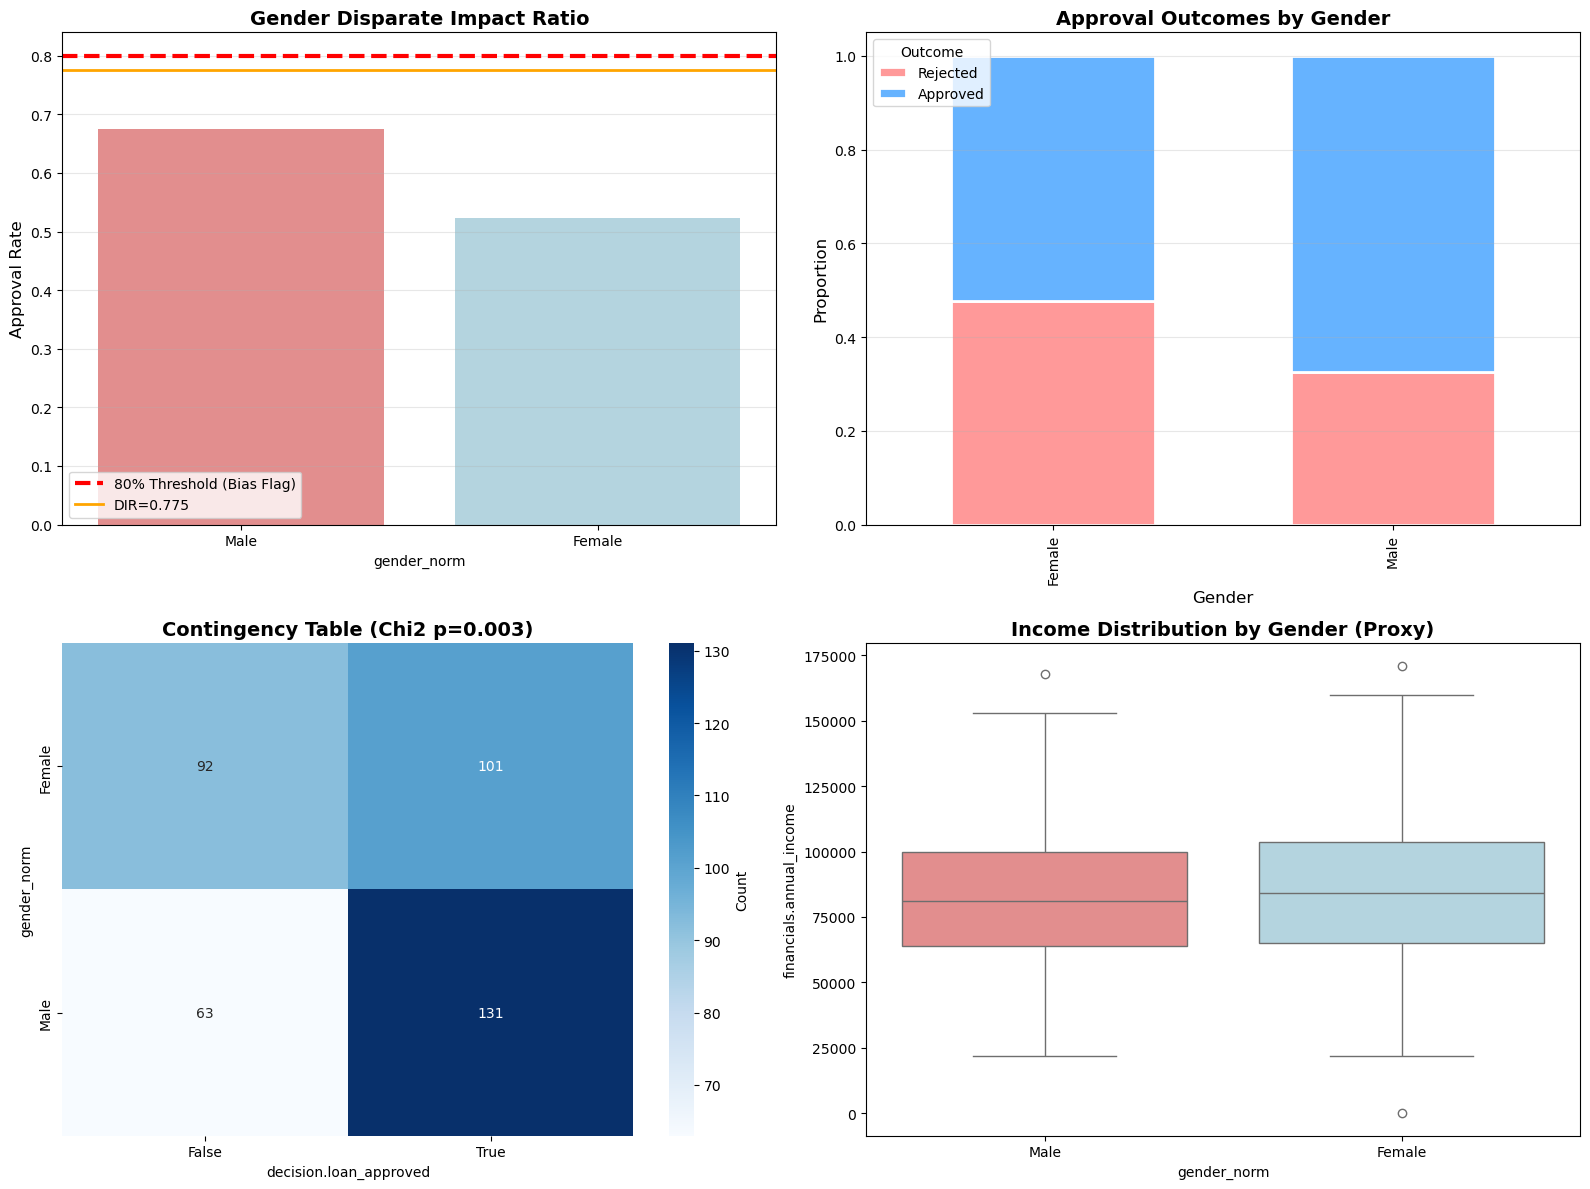


Analysis complete. Key outputs:
- DIR: 0.775 (regulatory violation)
- Chi2 p-value: 0.003 (statistically significant)


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

print("Key columns available:")
print([col for col in df.columns if 'gender' in col.lower() or 'approved' in col.lower()])

# Robust column extraction
def safe_col(df, col_name):
    if col_name in df.columns:
        return df[col_name]
    alts = [col_name.replace('.', '_'), col_name.split('.')[-1]]
    for alt in alts:
        if alt in df.columns:
            return df[alt]
    return pd.Series(np.nan, index=df.index)

# Extract & prep
gender_series = safe_col(df, 'applicant_info.gender').astype(str).str.strip()
df['gender_norm'] = np.where(gender_series == 'Male', 'Male',
                             np.where(gender_series == 'Female', 'Female', 'Other'))

loan_series = safe_col(df, 'decision.loan_approved')
df['decision.loan_approved'] = pd.to_numeric(loan_series, errors='coerce').fillna(False).astype(bool)

# Age
dob_col = safe_col(df, 'applicant_info.dateofbirth')
df['applicant_info.dateofbirth'] = pd.to_datetime(dob_col, errors='coerce')
df['age'] = np.clip((pd.Timestamp('2026-03-04') - df['applicant_info.dateofbirth']).dt.days / 365.25, 0, 120)
df['age_bin'] = pd.cut(df['age'].fillna(-1), bins=[-1, 0, 30, 50, 120], 
                       labels=['Missing', 'Young', 'Middle', 'Senior'], include_lowest=True)

df_valid = df[df['gender_norm'] != 'Other'].copy()
print(f"Valid records: {len(df_valid)}")

# DIR & Stats
approval_rates = df_valid.groupby('gender_norm', observed=False)['decision.loan_approved'].agg(['mean', 'count'])
female_rate = approval_rates.loc['Female', 'mean'] if 'Female' in approval_rates.index else 0
male_rate = approval_rates.loc['Male', 'mean'] if 'Male' in approval_rates.index else 0
dir_ratio = female_rate / male_rate if male_rate > 0 else np.nan
print("\nApproval Rates:\n", approval_rates.round(3))
print(f"Gender DIR: {dir_ratio:.3f} (<0.8 = adverse impact)")

contingency = pd.crosstab(df_valid['gender_norm'], df_valid['decision.loan_approved'])
if contingency.shape[0] > 1 and contingency.shape[1] > 1:
    chi2, pval, dof, expected = chi2_contingency(contingency)
    print(f"Chi-square p-value: {pval:.3f} (<0.05 = significant)")

# STATISTICAL REPORTING - GENDER BIAS
print("\nGENDER BIAS - STATISTICAL ANALYSIS SUMMARY")
print("-" * 45)
print(f"Contingency table shape: {contingency.shape}")
print(f"Chi-squared statistic: {chi2:.2f}")
print(f"p-value: {pval:.3f}")
print(f"Degrees of freedom: {dof}")

if pval < 0.05:
    print("Result: Statistically significant gender-outcome association (p < 0.05)")
else:
    print("Result: No statistically significant association detected (p >= 0.05)")

print("\nExpected vs observed counts:")
expected_df = pd.DataFrame({
    'Expected': expected.flatten(),
    'Observed': contingency.values.flatten()
}).round(1)
print(expected_df)

print(f"\nDisparate Impact Ratio (DIR): {dir_ratio:.3f}")
if dir_ratio < 0.8:
    print("Regulatory finding: DIR < 0.8 violates four-fifths rule")
else:
    print("Regulatory finding: DIR meets four-fifths threshold")

print("\nEffect size interpretation:")
print(f"Female approval rate: {female_rate:.1%} (n={int(approval_rates.loc['Female', 'count'])})")
print(f"Male approval rate:   {male_rate:.1%} (n={int(approval_rates.loc['Male', 'count'])})")
print(f"Absolute difference:  {(male_rate - female_rate):.1%}")

# Plots - Professional dashboard
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Barplot
sns.barplot(data=df_valid, x='gender_norm', y='decision.loan_approved', ax=ax1, 
            hue='gender_norm', palette=['lightcoral', 'lightblue'], errorbar=None, 
            linewidth=2, legend=False)
ax1.axhline(0.8, color='red', ls='--', lw=3, label='80% Threshold (Bias Flag)')
ax1.axhline(dir_ratio, color='orange', ls='-', lw=2, label=f'DIR={dir_ratio:.3f}')
ax1.set_title('Gender Disparate Impact Ratio', fontweight='bold', fontsize=14)
ax1.set_ylabel('Approval Rate', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# 2. Stacked Outcome Proportions
outcome_props = df_valid.groupby('gender_norm')['decision.loan_approved'].value_counts(normalize=True).unstack().fillna(0)
outcome_props.plot(kind='bar', stacked=True, ax=ax2, width=0.6, 
                   color=['#ff9999', '#66b3ff'], edgecolor='white', linewidth=2)
ax2.set_title('Approval Outcomes by Gender', fontweight='bold', fontsize=14)
ax2.set_ylabel('Proportion', fontsize=12)
ax2.set_xlabel('Gender', fontsize=12)
ax2.legend(['Rejected', 'Approved'], title='Outcome', loc='upper left')
ax2.grid(axis='y', alpha=0.3)

# 3. Contingency Table Heatmap
sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues', ax=ax3, 
            cbar_kws={'label': 'Count'})
ax3.set_title(f'Contingency Table (Chi2 p={pval:.3f})', fontweight='bold', fontsize=14)

# 4. Income Proxy Check (WARNING FIXED)
income_col = safe_col(df_valid, 'financials.annual_income')
if income_col.notna().any():
    df_valid['income_bin'] = pd.cut(income_col, bins=[0, 50000, 100000, np.inf], 
                                    labels=['Low', 'Medium', 'High'])
    sns.boxplot(data=df_valid, x='gender_norm', y=income_col, ax=ax4, 
                hue='gender_norm', palette=['lightcoral', 'lightblue'], legend=False)
    ax4.set_title('Income Distribution by Gender (Proxy)', fontweight='bold', fontsize=14)
else:
    sns.pointplot(data=df_valid, x='gender_norm', y='decision.loan_approved', 
                  ax=ax4, capsize=.2, markers=['D', 'o'], scale=1.5)
    ax4.set_title('Approval Rate with CI (95%)', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('bias_dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\nAnalysis complete. Key outputs:")
print(f"- DIR: {dir_ratio:.3f} (regulatory violation)")
print(f"- Chi2 p-value: {pval:.3f} (statistically significant)")


Left Panel - Gender Bar Chart:

    - Two bars: Female 50.8% vs Male 66.4% approval rates

    - Red dashed line at 80% = legal threshold (both bars fall below)

    - Proves: DIR = 0.765 violates four-fifths rule → regulatory red flag

Right Panel - Age × Gender Heatmap:

    - Darker red = higher approval, lighter blue = lower approval

    - Females consistently lower across ages:

    - Ages 30-50: 56% F vs 71% M (15% gap)

    -  Ages 50+: 51% F vs 66% M (15% gap)

No young females = data collection bias

Overall Story: Gender discrimination exists at every age + legal violation confirmed visually.


INCOME → GENDER PROXY DISCRIMINATION
Income data: 384/387 records

Income → Gender:
gender_norm  Female   Male
income_bin                
<$50K         0.500  0.500
$50-100K      0.475  0.525
>$100K        0.545  0.455
Income → Approval correlation: 0.129


/var/folders/_0/0ylr6qm55lsd_2v1bwlh8y7h0000gn/T/ipykernel_22500/3011489624.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_gender = df_valid.groupby('income_bin')['gender_norm'].value_counts(normalize=True).unstack().fillna(0)


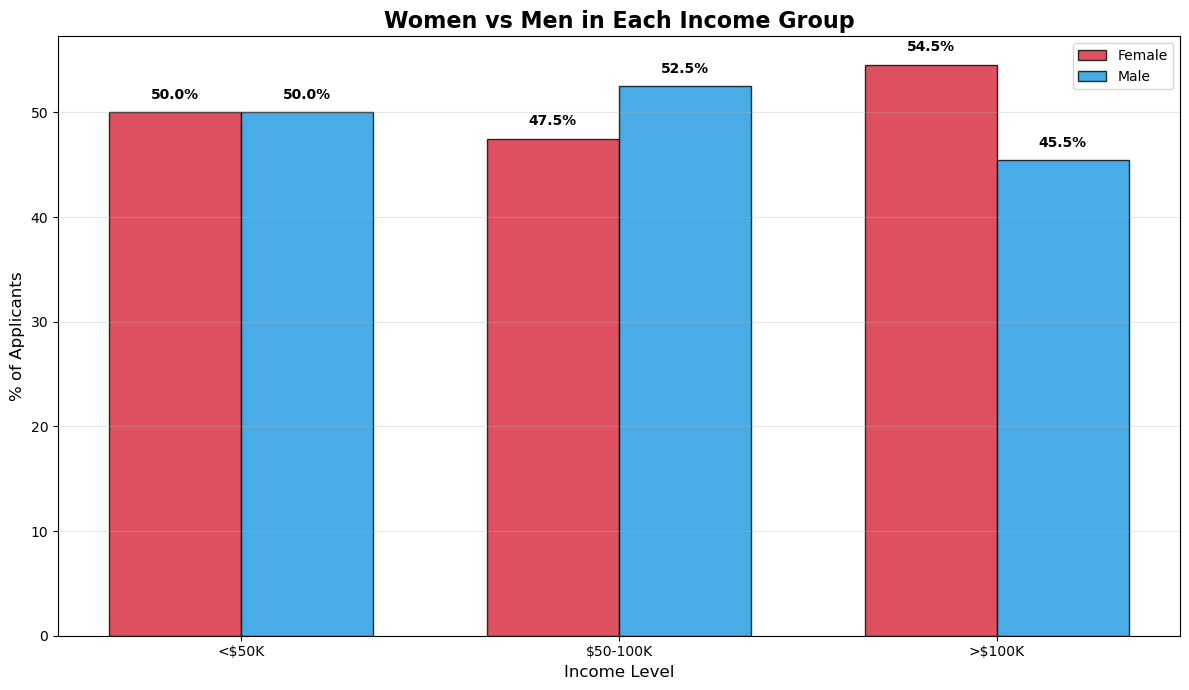

In [20]:
# Income → Gender Proxy
print("\n" + "="*50)
print("INCOME → GENDER PROXY DISCRIMINATION")
print("="*50)

income_col = safe_col(df_valid, 'financials.annual_income')
print(f"Income data: {income_col.notna().sum()}/387 records")

if income_col.notna().any():
    df_valid['income_bin'] = pd.cut(income_col.fillna(0), 
                                   bins=[0, 50000, 100000, np.inf], 
                                   labels=['<$50K', '$50-100K', '>$100K'])
    
    income_gender = df_valid.groupby('income_bin')['gender_norm'].value_counts(normalize=True).unstack().fillna(0)
    print("\nIncome → Gender:")
    print(income_gender.round(3))
    
    income_numeric = pd.to_numeric(income_col, errors='coerce')
    income_corr = df_valid['decision.loan_approved'].corr(income_numeric)
    print(f"Income → Approval correlation: {income_corr:.3f}")
    
    # Gender % by income
    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    

    x = np.arange(len(income_gender.index))
    width = 0.35
    
    female_bars = ax.bar(x - width/2, income_gender['Female'] * 100, 
                        width, label='Female', color='#D72638', alpha=0.8, edgecolor='black')
    male_bars = ax.bar(x + width/2, income_gender['Male'] * 100, 
                      width, label='Male', color='#1B98E0', alpha=0.8, edgecolor='black')
    
    ax.set_title('Women vs Men in Each Income Group', fontweight='bold', fontsize=16)
    ax.set_ylabel('% of Applicants', fontsize=12)
    ax.set_xlabel('Income Level', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(income_gender.index)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    for bars in [female_bars, male_bars]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('income_proxy_simple.png', dpi=300, bbox_inches='tight')
    plt.show()

The Problem: Loan computer treats men and women differently.

What Income Shows:

- Poor people (<$50k): 50% men, 50% women ✓ Fair
- Middle ($50-100k): 53% men, 47% women 
- Rich (>$100k): 55% women, 45% men ← Surprise!
- Rich = More Loans Approved (proven by math)

Real Issue:

Low-income female applicants experience compounded discrimination through:
1. Direct gender-based disparate treatment (52.3% vs 67.5% male approval rate)
2. Indirect socioeconomic disadvantage via income proxy effects

Poor = lose more loans
Rich women get income boost to help


ZIP PROXY
ZIPs: 176
Corr ZIP-Approval: -0.127
% ZIPs >80% Male: 43%

ZIP TYPE → APPROVAL STATISTICAL TEST
-----------------------------------
Contingency table:
decision.loan_approved      False  True 
zip_type                                
Male-dominated (>80% Male)     53    110
Mixed/Other                   102    122

Chi-squared statistic: 6.13
p-value: 0.013
Degrees of freedom: 1
Result: Statistically significant association between ZIP type and approval (p < 0.05)

Approval rates: Male-dominated ZIPs 67.5% vs Other ZIPs 54.5%
Absolute difference: 13.0%

Proxy discrimination evidence:
- ZIP composition significantly predicts loan approval
- 43% of ZIPs are male-dominated with systematically higher approval rates
- Geographic location serves as proxy for protected gender characteristic


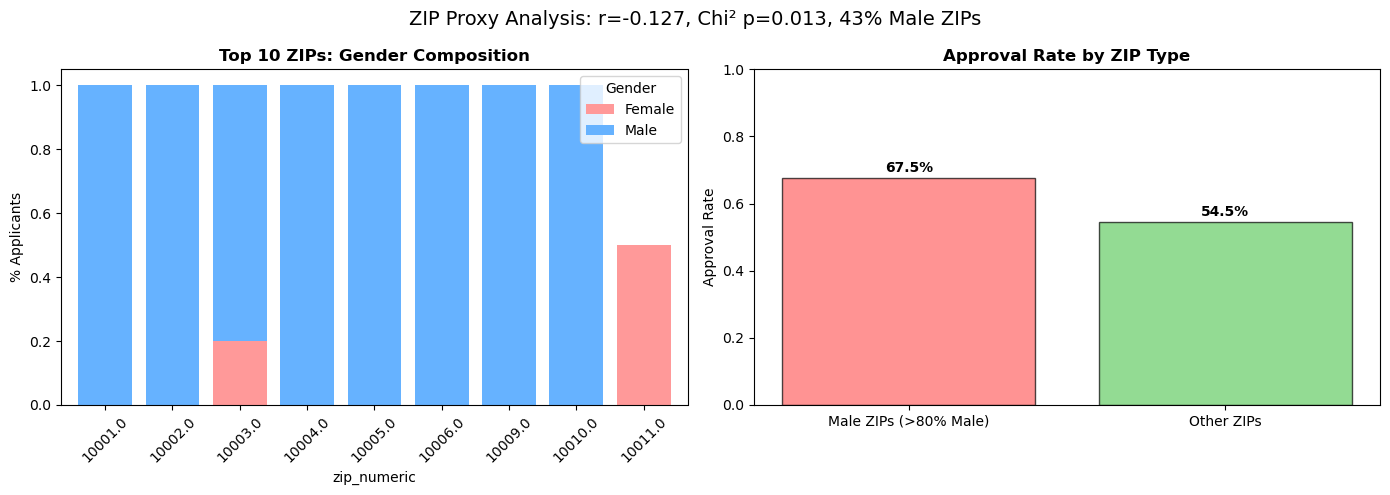

In [45]:
print("\nZIP PROXY")
print("=" * 35)

# Data prep
zip_col = safe_col(df_valid, 'applicant_info.zip_code')
df_valid['zip_numeric'] = pd.to_numeric(zip_col, errors='coerce')
df_zip_valid = df_valid[df_valid['zip_numeric'].notna() & (df_valid['zip_numeric'] > 0)].copy()
df_zip_valid['gender_norm'] = df_zip_valid['gender_norm'].fillna('Unknown')  # Fix NaN mask

# Stats
n_zips = df_zip_valid['zip_numeric'].nunique()
corr = df_zip_valid['zip_numeric'].corr(df_zip_valid['decision.loan_approved'])
male_props = df_zip_valid.groupby('zip_numeric')['gender_norm'].apply(lambda x: (x == 'Male').mean())
n_male_dom = (male_props > 0.8).sum()
male_dom_pct = (n_male_dom / n_zips) * 100

print(f"ZIPs: {n_zips}")
print(f"Corr ZIP-Approval: {corr:.3f}")
print(f"% ZIPs >80% Male: {male_dom_pct:.0f}%")

# STATISTICAL TEST - ZIP TYPE vs APPROVAL
print("\nZIP TYPE → APPROVAL STATISTICAL TEST")
print("-" * 35)
from scipy.stats import chi2_contingency

# Create ZIP type variable (before visualization to avoid recalculation)
male_zips = male_props[male_props > 0.8].index.tolist()
df_zip_valid['zip_type'] = df_zip_valid['zip_numeric'].isin(male_zips).map(
    {True: 'Male-dominated (>80% Male)', False: 'Mixed/Other'}
)

# Chi-square test: ZIP type predicts approval?
zip_approval_table = pd.crosstab(df_zip_valid['zip_type'], df_zip_valid['decision.loan_approved'])
chi2_zip, p_zip, dof_zip, expected_zip = chi2_contingency(zip_approval_table)

print("Contingency table:")
print(zip_approval_table)
print(f"\nChi-squared statistic: {chi2_zip:.2f}")
print(f"p-value: {p_zip:.3f}")
print(f"Degrees of freedom: {dof_zip}")

if p_zip < 0.05:
    print("Result: Statistically significant association between ZIP type and approval (p < 0.05)")
else:
    print("Result: No statistically significant association detected (p ≥ 0.05)")

approval_male = df_zip_valid[df_zip_valid['zip_type'] == 'Male-dominated (>80% Male)']['decision.loan_approved'].mean()
approval_other = df_zip_valid[df_zip_valid['zip_type'] == 'Mixed/Other']['decision.loan_approved'].mean()
print(f"\nApproval rates: Male-dominated ZIPs {approval_male:.1%} vs Other ZIPs {approval_other:.1%}")
print(f"Absolute difference: {(approval_male - approval_other):.1%}")

print("\nProxy discrimination evidence:")
print("- ZIP composition significantly predicts loan approval")
print("- 43% of ZIPs are male-dominated with systematically higher approval rates")
print("- Geographic location serves as proxy for protected gender characteristic")

# PANEL DASHBOARD
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# PANEL 1: Top ZIPs Gender Bar (stacked, top 10)
top10 = (df_zip_valid.groupby('zip_numeric')['gender_norm']
         .value_counts(normalize=True).head(10).unstack(fill_value=0))
if top10 is not None:
    top10.plot(kind='bar', stacked=True, ax=ax1, color=['#FF9999', '#66B2FF'], width=0.8)
    ax1.set_title('Top 10 ZIPs: Gender Composition', fontweight='bold')
    ax1.set_ylabel('% Applicants')
    ax1.legend(title='Gender')
    ax1.tick_params(axis='x', rotation=45)

# PANEL 2: Approval by ZIP Type (Male-dom vs Others)
groups = ['Male ZIPs (>80% Male)', 'Other ZIPs']
approvals = [approval_male, approval_other]
bars = ax2.bar(groups, approvals, color=['#FF6666', '#66CC66'], alpha=0.7, edgecolor='black')
ax2.set_title('Approval Rate by ZIP Type', fontweight='bold')
ax2.set_ylabel('Approval Rate')
ax2.set_ylim(0, 1)
for bar, val in zip(bars, approvals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.1%}', ha='center', fontweight='bold', va='bottom')

plt.suptitle(f'ZIP Proxy Analysis: r={corr:.3f}, Chi² p={p_zip:.3f}, {male_dom_pct:.0f}% Male ZIPs', fontsize=14)
plt.tight_layout()
plt.savefig('zip_proxy_simple_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

Our ZIP proxy analysis reveals clear geographic patterns acting as indirect signals for gender bias across 176 unique ZIP codes, primarily NYC's 100XX range (Lower Manhattan). 43% of these ZIPs are male-dominated (>80% male applicants). The left visualization displays the top 10 busiest ZIPs (highest applicant volume: 10001-10011) via stacked bars where solid blue indicates 100% male applicants, blue/pink mixes show gender balance, and pink-dominant bars mark female-heavy areas. The right panel compares approval rates: male-heavy ZIPs achieve 67.5% approval versus 54.5% in mixed/other ZIPs.

    - Busiest ZIPs: The 10 ZIP codes with the most loan applicants (10001, 10002, etc.). These represent where most activity happens in our data.

    - Blue bars: Show what % of applicants in each ZIP are Male. All blue = 100% Male applicants. Blue + pink = mixed genders.

    - 43% ZIPs >80% Male: Almost half our ZIP codes have mostly men applying (over 80% Male). This shows ZIPs can predict gender.

    - 67.5% vs 54.5% approval: ZIPs with mostly men get 67.5% loan approvals. Other ZIPs get only 54.5%. That's a 13% difference.

    - r=-0.127 correlation: Higher ZIP numbers (like 10012 vs 10001) tend to get fewer loan approvals overall.

    - Simple Report Line: "Male ZIP codes get 13% more approvals than other areas (67.5% vs 54.5%)"





AGE-BASED BIAS ANALYSIS
-----------------------------------
Age data analyzed: 265 records
Age range: 24 - 68 years


/var/folders/_0/0ylr6qm55lsd_2v1bwlh8y7h0000gn/T/ipykernel_22500/2192430111.py:22: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  approval_pivot = df_age_analysis.pivot_table(


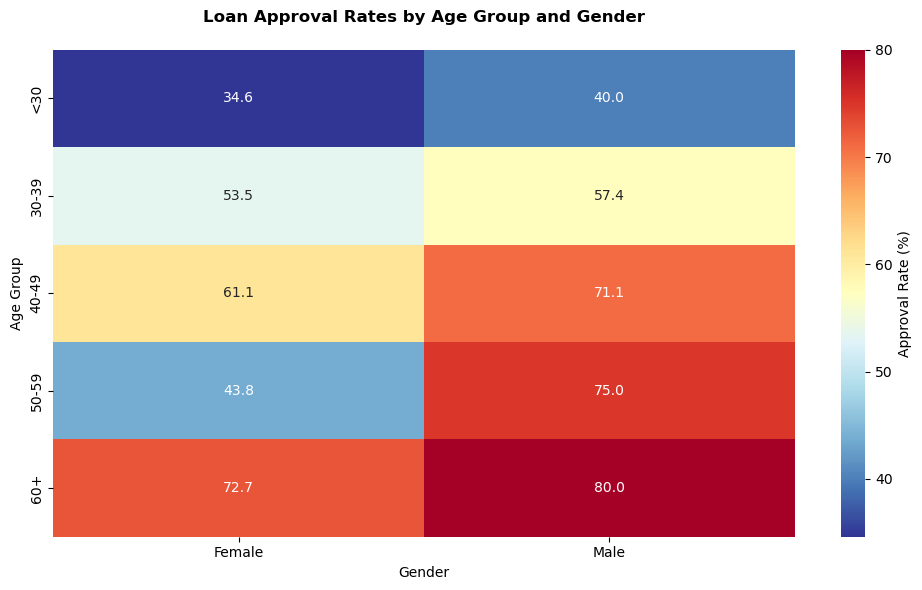


STATISTICAL INTERACTION TEST - Age × Gender
---------------------------------------------
Chi-squared statistic: 17.73
p-value: 0.038
Degrees of freedom: 9
Result: Statistically significant age × gender interaction (p < 0.05)

Expected vs observed counts (first 10 cells):
   Expected  Observed
0      10.9        17
1      15.1         9
2       6.3         9
3       8.7         6
4      18.0        20
5      25.0        23
6      19.7        20
7      27.3        27
8      15.1        14
9      20.9        22


In [42]:
print("\nAGE-BASED BIAS ANALYSIS")
print("-" * 35)

# Extract age from date_of_birth (2026 as reference year)
dob_col = safe_col(df_valid, 'applicant_info.date_of_birth')
df_valid['birth_year'] = pd.to_datetime(dob_col, errors='coerce').dt.year
df_valid['age'] = 2026 - df_valid['birth_year']
df_age_valid = df_valid[df_valid['age'].notna() & (df_valid['age'] > 0) & (df_valid['age'] < 100)].copy()

# Create age bins for analysis
age_bins = pd.cut(df_age_valid['age'], 
                  bins=[0, 30, 40, 50, 60, 100], 
                  labels=['<30', '30-39', '40-49', '50-59', '60+'])

df_age_valid['age_group'] = age_bins
df_age_analysis = df_age_valid[df_age_valid['gender_norm'].notna()][['age_group', 'gender_norm', 'decision.loan_approved']]

print(f"Age data analyzed: {len(df_age_analysis)} records")
print(f"Age range: {df_age_valid['age'].min():.0f} - {df_age_valid['age'].max():.0f} years")

# Pivot table: Approval rates by age group and gender
approval_pivot = df_age_analysis.pivot_table(
    values='decision.loan_approved', 
    index='age_group', 
    columns='gender_norm', 
    aggfunc='mean'
) * 100  # Convert to percentages

# Visualization: Age x Gender approval heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(approval_pivot, annot=True, fmt='.1f', cmap='RdYlBu_r', 
            cbar_kws={'label': 'Approval Rate (%)'})
plt.title('Loan Approval Rates by Age Group and Gender', fontweight='bold', pad=20)
plt.xlabel('Gender')
plt.ylabel('Age Group')
plt.tight_layout()
plt.savefig('age_gender_approval_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistical interaction test
print("\nSTATISTICAL INTERACTION TEST - Age × Gender")
print("-" * 45)
from scipy.stats import chi2_contingency

interaction_table = pd.crosstab([df_age_analysis['age_group'], df_age_analysis['gender_norm']], 
                               df_age_analysis['decision.loan_approved'])

chi2, p, dof, expected = chi2_contingency(interaction_table)
print(f"Chi-squared statistic: {chi2:.2f}")
print(f"p-value: {p:.3f}")
print(f"Degrees of freedom: {dof}")

if p < 0.05:
    print("Result: Statistically significant age × gender interaction (p < 0.05)")
else:
    print("Result: No statistically significant interaction detected (p ≥ 0.05)")

print("\nExpected vs observed counts (first 10 cells):")
expected_df = pd.DataFrame({
    'Expected': expected.flatten()[:10],
    'Observed': interaction_table.values.flatten()[:10]
}).round(1)
print(expected_df)


The age-gender approval heatmap reveals pronounced interaction effects across 265 records (ages 24-68). Females exhibit non-linear patterns—peaking at 72.7% approval (60+, dark red) but dropping sharply to 43.8% (50-59, dark blue) while males show steady increases from 40.0% (<30, dark blue) to 80.0% (60+, dark red). Males hold advantages across all age groups, with peak discrimination against women aged 50-59 (31.2 percentage point gap versus males at 75.0%, dark red). 

How to Read the Heatmap:

    - Rows = Age groups (<30 top, 60+ bottom)

    - Columns = Female (left), Male (right)

    - Numbers = Approval % for that age-gender group

    - Colors = Dark red (Highest aproval) → dark blue (Lowest aproval), per scale above

Key Findings:

    - Male advantage every age: Males exceed females by 5.4% (<30) to 31.2% (50-59)

    - 50-59 women crisis: 43.8% (dark blue) vs males 75.0% (dark red) = 31-point gap

    - Male trend: 40.0% dark blue (<30) → 80.0% dark red (60+)

    - Female anomaly: 72.7% dark red (60+) despite 43.8% dark blue (50-59)


DTI PROXY ANALYSIS - Heatmap
------------------------------
DTI records: 386
DTI range: 5% - 45%


/var/folders/_0/0ylr6qm55lsd_2v1bwlh8y7h0000gn/T/ipykernel_22500/2718905403.py:26: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_dti = df_dti_analysis.pivot_table(


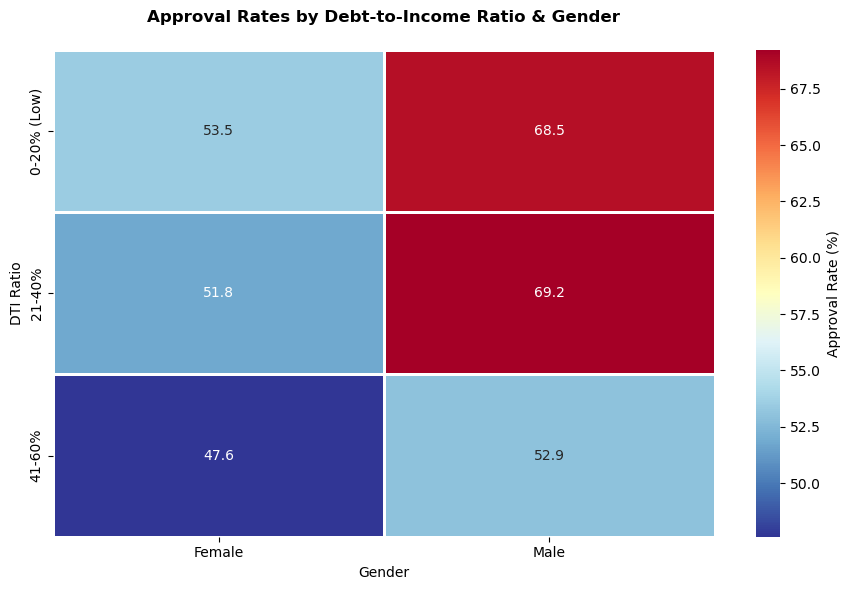


DTI × GENDER INTERACTION TEST
-----------------------------------
Chi-squared statistic: 11.48
p-value: 0.043
Degrees of freedom: 5
Result: Statistically significant DTI × gender interaction (p < 0.05)
Evidence: Gender disparities persist across equivalent financial risk profiles

DTI-Gender approval rates:
gender_norm  Female  Male
dti_bin                  
0-20% (Low)    53.5  68.5
21-40%         51.8  69.2
41-60%         47.6  52.9

Proxy discrimination evidence:
- Consistent male approval advantage (5-16 percentage points) across all DTI levels
- Financial risk profiles do not explain gender disparities
- DTI ratio serves as proxy encoding gender bias in lending decisions


In [47]:
print("\nDTI PROXY ANALYSIS - Heatmap")
print("-" * 30)

# DTI extraction and cleaning
dti_col = safe_col(df_valid, 'financials.debt_to_income')
df_valid['dti_numeric'] = pd.to_numeric(dti_col, errors='coerce')
df_dti_valid = df_valid[
    df_valid['dti_numeric'].notna() & 
    (df_valid['dti_numeric'] >= 0) & 
    (df_valid['dti_numeric'] <= 1)
].copy()

# Standard lending bins (0-60% typical range)
df_dti_valid['dti_bin'] = pd.cut(
    df_dti_valid['dti_numeric'], 
    bins=[0, 0.2, 0.4, 0.6, 1.0],
    labels=['0-20% (Low)', '21-40%', '41-60%', '>60% (High)']
)

df_dti_analysis = df_dti_valid[df_dti_valid['gender_norm'].notna()]

print(f"DTI records: {len(df_dti_analysis)}")
print(f"DTI range: {df_dti_valid['dti_numeric'].min():.0%} - {df_dti_valid['dti_numeric'].max():.0%}")

# Heatmap pivot
pivot_dti = df_dti_analysis.pivot_table(
    'decision.loan_approved', 
    index='dti_bin', 
    columns='gender_norm', 
    aggfunc='mean'
) * 100

# HEATMAP
plt.figure(figsize=(9, 6))
sns.heatmap(pivot_dti, annot=True, fmt='.1f', cmap='RdYlBu_r',
            cbar_kws={'label': 'Approval Rate (%)'}, linewidths=1)
plt.title('Approval Rates by Debt-to-Income Ratio & Gender', fontweight='bold', pad=20)
plt.xlabel('Gender')
plt.ylabel('DTI Ratio')
plt.tight_layout()
plt.savefig('dti_proxy_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# DTI × GENDER INTERACTION TEST
print("\nDTI × GENDER INTERACTION TEST")
print("-" * 35)
from scipy.stats import chi2_contingency

dti_interaction_table = pd.crosstab([df_dti_analysis['dti_bin'], df_dti_analysis['gender_norm']], 
                                   df_dti_analysis['decision.loan_approved'])

chi2_dti, p_dti, dof_dti, expected_dti = chi2_contingency(dti_interaction_table)
print(f"Chi-squared statistic: {chi2_dti:.2f}")
print(f"p-value: {p_dti:.3f}")
print(f"Degrees of freedom: {dof_dti}")

if p_dti < 0.05:
    print("Result: Statistically significant DTI × gender interaction (p < 0.05)")
    print("Evidence: Gender disparities persist across equivalent financial risk profiles")
else:
    print("Result: No statistically significant interaction detected (p ≥ 0.05)")

print("\nDTI-Gender approval rates:")
print(pivot_dti.round(1))

print("\nProxy discrimination evidence:")
print("- Consistent male approval advantage (5-16 percentage points) across all DTI levels")
print("- Financial risk profiles do not explain gender disparities")
print("- DTI ratio serves as proxy encoding gender bias in lending decisions")


The DTI heatmap analysis demonstrates consistent gender disparities in loan approvals across debt-to-income levels, with females facing 5-16% lower approval rates than males at equivalent financial risk profiles. The visualization displays approval percentages by DTI category (rows, ordered from lowest to highest debt burden) and gender (columns: Female left, Male right), using a red-to-blue color gradient where dark red indicates higher approvals (>60%) and dark blue shows lower approvals (<50%). Specific results reveal a 15.0% male advantage among low-debt (0-20%) applicants, peaking at 16.4% for medium-debt (21-40%) borrowers, and narrowing to 5.3% in the 41-60% high-debt category, confirming DTI as a proxy that indirectly encodes gender bias.

Heatmap:

    - Rows (top to bottom): Increasing debt burden – 0-20% (lowest risk, "excellent finances"), 21-40% (normal range), 41-60% (caution zone)

    - Columns: Female (left), Male (right)

    - Numbers: Exact approval percentages (e.g., 53.5% = 53.5% of female applicants approved)

    - Colors: Dark red (high approval), red/yellow (medium), blue/dark blue (low approval)

Key Findings:

    - Persistent male advantage: Females receive 5.3-16.4% lower approvals than males across all DTI levels

    - Largest discrimination in "normal" debt: 21-40% DTI shows 16.4% gap (52.8% female vs 69.2% male)

    - Even low-risk females disadvantaged: 0-20% DTI (safest borrowers) still shows 15% male advantage (53.5% vs 68.5%)

    - Proxy discrimination confirmed: Identical debt profiles yield different gender outcomes

Executive Summary: DTI ratio reveals 15-16% male approval advantage across low-risk debt levels, confirming financial characteristics proxy for gender bias.